<div style="background:linear-gradient(135deg,#431407 0%,#c2410c 55%,#fb923c 100%);border-radius:18px;padding:30px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ffedd5;font-weight:700;text-transform:uppercase">Chapter 95 · Solutions</div>
  <div style="font-size:30px;font-weight:900;line-height:1.1;margin:10px 0 6px">Chapter 95 &#183; Solutions</div>
  <div style="font-size:14px;color:#fff7ed;max-width:740px;line-height:1.6">Five challenges, each verified in code.</div>

</div>

Solutions to the five challenges from Chapter 95, using the statsmodels diagnostic tools.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, regplots, pairplots)
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
ORG="#ea580c"; DEEP="#c2410c"; LIGHT="#fdba74"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera, durbin_watson
try:
    ins = pd.read_excel('../../data/ch95_insurance.xlsx', sheet_name='Policies')
except FileNotFoundError:
    ins = pd.read_excel(BASE + 'ch95_insurance.xlsx', sheet_name='Policies')
m = ols('charges ~ age + bmi + C(smoker)', ins).fit()

<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#c2410c;letter-spacing:1px">CHALLENGE 1</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">Build the diagnostic dashboard</div>
<div style="color:#4a5578;margin-top:5px">Residual-vs-fitted, Q-Q, scale-location.</div>
</div>

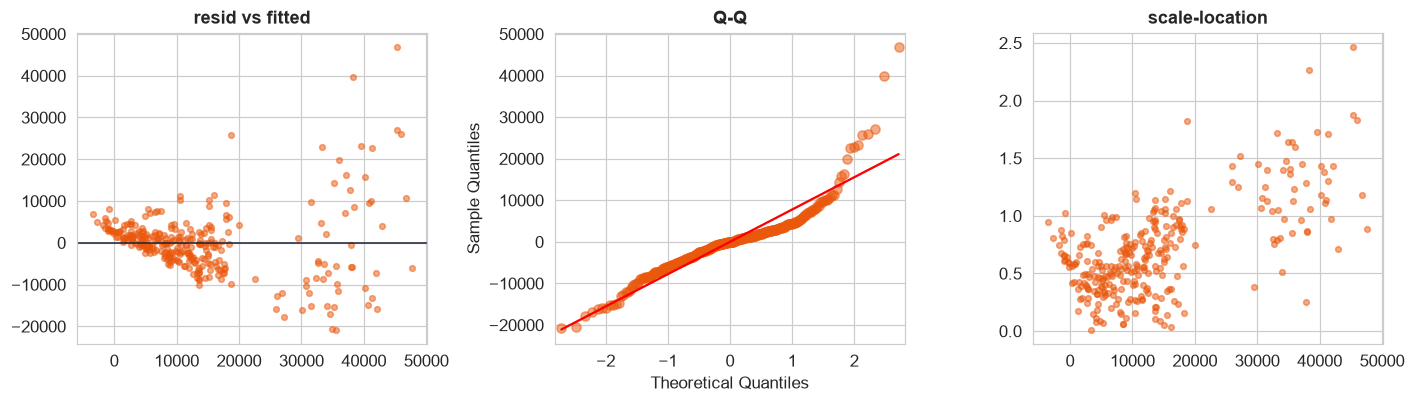

In [3]:
fig, ax = plt.subplots(1,3, figsize=(13,3.8))
ax[0].scatter(m.fittedvalues, m.resid, s=14, color=ORG, alpha=0.5); ax[0].axhline(0,color=INK,lw=1); ax[0].set_title('resid vs fitted')
sm.qqplot(m.resid, line='s', ax=ax[1], markerfacecolor=ORG, markeredgecolor=ORG, alpha=0.5); ax[1].set_title('Q-Q')
stud = m.get_influence().resid_studentized_internal
ax[2].scatter(m.fittedvalues, np.sqrt(np.abs(stud)), s=14, color=ORG, alpha=0.5); ax[2].set_title('scale-location')
plt.tight_layout(); plt.show()

<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#c2410c;letter-spacing:1px">CHALLENGE 2</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">Test every assumption</div>
<div style="color:#4a5578;margin-top:5px">BP, JB, DW.</div>
</div>

In [4]:
print(f'Breusch-Pagan p = {het_breuschpagan(m.resid,m.model.exog)[1]:.4f} (equal variance)')
print(f'Jarque-Bera   p = {jarque_bera(m.resid)[1]:.4f} (normality)')
print(f'Durbin-Watson   = {durbin_watson(m.resid):.2f} (independence)')
print('Equal variance and normality FAIL in levels; independence OK.')

Breusch-Pagan p = 0.0000 (equal variance)
Jarque-Bera   p = 0.0000 (normality)
Durbin-Watson   = 2.17 (independence)
Equal variance and normality FAIL in levels; independence OK.


<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#c2410c;letter-spacing:1px">CHALLENGE 3</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">Fix it with a log</div>
<div style="color:#4a5578;margin-top:5px">Refit on log(charges).</div>
</div>

In [5]:
mlog = ols('np.log(charges) ~ age + bmi + C(smoker)', ins).fit()
print(f'levels BP p = {het_breuschpagan(m.resid,m.model.exog)[1]:.4f}  ->  log BP p = {het_breuschpagan(mlog.resid,mlog.model.exog)[1]:.3f}')
print(f'levels JB p = {jarque_bera(m.resid)[1]:.4f}  ->  log JB p = {jarque_bera(mlog.resid)[1]:.3f}')
print(f'R2: {m.rsquared:.3f} -> {mlog.rsquared:.3f}')

levels BP p = 0.0000  ->  log BP p = 0.879
levels JB p = 0.0000  ->  log JB p = 0.498
R2: 0.701 -> 0.781


<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#c2410c;letter-spacing:1px">CHALLENGE 4</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">Find influential points</div>
<div style="color:#4a5578;margin-top:5px">Leverage, studentized residuals, Cook's distance.</div>
</div>

In [6]:
infl = m.get_influence(); cook = infl.cooks_distance[0]
top = np.argsort(cook)[::-1][:5]
print(pd.DataFrame({'obs':top, 'cooks_D':cook[top].round(3), 'leverage':infl.hat_matrix_diag[top].round(3)}))

   obs  cooks_D  leverage
0  174    0.261     0.028
1   34    0.134     0.020
2  245    0.091     0.029
3  269    0.083     0.029
4  236    0.072     0.039


<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#c2410c;letter-spacing:1px">CHALLENGE 5</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">Refit without the influencers</div>
<div style="color:#4a5578;margin-top:5px">Robustness check.</div>
</div>

In [7]:
thr = 4/len(ins); flag = np.where(cook>thr)[0]
refit = ols('charges ~ age + bmi + C(smoker)', ins[~ins.index.isin(flag)]).fit()
print(pd.DataFrame({'all':m.params.round(2), 'without':refit.params.round(2)}))
print(f'dropped {len(flag)} points; conclusions stable if coefficients barely move.')

                       all   without
Intercept        -17636.37 -11146.34
C(smoker)[T.yes]  27434.75  25421.54
age                 381.10    266.09
bmi                 352.57    291.94
dropped 30 points; conclusions stable if coefficients barely move.


---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>